In [1]:
# !pip install points2regions
# !pip install geopandas
# !pip install fastparquet
# !pip install pyarrow

In [2]:
from points2regions import Points2Regions
import pandas as pd
import geopandas as gpd

In [3]:
sample = "Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs"
data_dir = "data"
results_dir = "results"

In [4]:
trx = pd.read_parquet(f"{data_dir}/{sample}/transcripts.parquet", engine="fastparquet")
trx

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv
0,281474976710658,7703,0,b'Dkk3',4820.325684,768.679260,15.693588,16.515629
1,281474976710659,7704,0,b'Dkk3',4820.890137,731.118469,15.173458,22.901026
2,281474976710661,7704,0,b'Dkk3',4821.784180,733.212402,14.517880,15.178098
3,281474976710664,7886,0,b'Bhlhe40',4824.487793,656.776123,15.052075,22.886139
4,281474976710665,7704,1,b'Bhlhe40',4825.741211,737.871826,17.312185,31.846781
...,...,...,...,...,...,...,...,...
11791432,281599531251574,35282,0,b'Acsbg1',3639.523926,2848.172607,14.729904,40.000000
11791433,281599531251575,35995,1,b'Rprm',3639.247070,2779.447266,15.175095,23.390734
11791434,281599531251577,36115,0,b'Sema6a',3640.472656,3067.596436,13.888914,40.000000
11791435,281599531251579,5454,1,b'Nell1',3639.496094,3456.907715,13.969896,40.000000


In [5]:
data = trx[['transcript_id', 'feature_name', 'x_location', 'y_location']]
data.head()

,transcript_id,feature_name,x_location,y_location
0,281474976710658,b'Dkk3',4820.325684,768.679260
1,281474976710659,b'Dkk3',4820.890137,731.118469
2,281474976710661,b'Dkk3',4821.784180,733.212402
3,281474976710664,b'Bhlhe40',4824.487793,656.776123
4,281474976710665,b'Bhlhe40',4825.741211,737.871826


In [6]:
del trx 

In [7]:
pixel_smoothing = 100

In [8]:
# Create the clustering model
p2r = Points2Regions(
    data[['x_location', 'y_location']], 
    data['feature_name'], 
    pixel_width=1, 
    pixel_smoothing=pixel_smoothing
)

In [9]:
p2r

In [10]:
import types
import numpy as np
import scipy.sparse as sp
from sklearn.cluster import MiniBatchKMeans as KMeans
from points2regions._points2regions import _merge_clusters, _compute_cluster_center

def _cluster_patched(self, num_clusters:int, seed:int=42, kmeans_kwargs=None):
    """Monkey patch to fix 64-bit sparse index issue inside Points2Regions._cluster()."""

    # Build feature matrix
    self.X_train = sp.vstack([
        result['features'][result['passed_threshold']]
        for result in self._results.values()
    ])

    # Ensure 32-bit indices for scikit-learn
    if sp.issparse(self.X_train):
        self.X_train = self.X_train.asformat("csr")
        self.X_train.indices = self.X_train.indices.astype(np.int32)
        self.X_train.indptr = self.X_train.indptr.astype(np.int32)

    # Default KMeans params
    default_kmeans_kwargs = dict(
        init="k-means++", max_iter=100, batch_size=1024, verbose=0,
        compute_labels=True, random_state=seed, tol=0.0,
        max_no_improvement=10, init_size=None, n_init="auto",
        reassignment_ratio=0.005,
    )

    if kmeans_kwargs is not None:
        for key, val in kmeans_kwargs.items():
            if key in default_kmeans_kwargs:
                default_kmeans_kwargs[key] = val

    if isinstance(default_kmeans_kwargs['init'], sp.spmatrix):
        n_kmeans_clusters = default_kmeans_kwargs['init'].shape[0]
        use_hierarchial = False
    elif isinstance(default_kmeans_kwargs['init'], np.ndarray):
        n_kmeans_clusters = default_kmeans_kwargs['init'].shape[0]
        use_hierarchial = False
    else:
        n_kmeans_clusters = int(1.5 * num_clusters)
        use_hierarchial = True

    kmeans = KMeans(n_kmeans_clusters, **default_kmeans_kwargs)
    kmeans = kmeans.fit(self.X_train)
    self.inertia = kmeans.inertia_

    # Merge clusters if needed
    if use_hierarchial:
        clusters = _merge_clusters(kmeans, num_clusters)
        _, self.cluster_centers = _compute_cluster_center(clusters, kmeans.cluster_centers_)
    else:
        clusters = kmeans.labels_
        self.cluster_centers = kmeans.cluster_centers_

    # Assign clusters per dataset
    for datasetid, result_dict in self._results.items():
        features = result_dict['features']
        passed_threshold = result_dict['passed_threshold']
        pix2marker_ind = result_dict['pix2marker_ind']

        kmeans_clusters = kmeans.predict(features[passed_threshold])
        merged_clusters = clusters[kmeans_clusters]

        cluster_per_pixel = np.zeros(features.shape[0], dtype=int) - 1
        cluster_per_pixel[passed_threshold] = merged_clusters
        cluster_per_marker = cluster_per_pixel[pix2marker_ind]

        self._results[datasetid]['cluster_per_marker'] = cluster_per_marker
        self._results[datasetid]['cluster_per_pixel'] = cluster_per_pixel

    self._num_points = len(self._xy)
    self._set_cluster_colors()
    self._is_clustered = True
    return self

# --- attach the patched method to your instance ---
p2r._cluster = types.MethodType(_cluster_patched, p2r)

In [11]:
# # Cluster with a specified number of clusters
# p2r.fit(num_clusters=20)

# # Get cluster label for each marker
# cluster_per_marker = p2r.predict(output='marker')

# # Get a label mask
# label_mask, tform = p2r.predict(output='pixel')

# # Get connected components
# connected_components, num_components, label_mask, tform  = p2r.predict(output='connected')

In [12]:
# connected_components, num_components, label_mask, tform  = p2r.predict(output='connected', grow=5)
# geojson = p2r.predict(output='geojson')
# gdf = gpd.GeoDataFrame.from_features(geojson["features"])
# gdf.head()
# gdf.to_parquet(f"{results_dir}/p2r_multipolygons.parquet")

# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import geopandas as gpd

# # Convert RGB lists (e.g. [230, 25, 75]) to normalized RGB tuples
# gdf["color_hex"] = gdf["color"].apply(lambda c: mcolors.to_hex([v/255 for v in c]))

In [13]:
# gdf_single = gdf.explode(index_parts=True, ignore_index=True)

# # Plot with those colors
# fig, ax = plt.subplots(figsize=(10, 10))
# gdf_single.plot(ax=ax, edgecolor=gdf_single["color_hex"],  facecolor="none", linewidth=0.5)

# plt.title("Cluster Polygons", fontsize=14)
# plt.show()

# gdf_single.to_parquet(f"{results_dir}/p2r_polygons.parquet")

In [14]:
# for i, row in gdf_single.iterrows():
#     fig, ax = plt.subplots(figsize=(8, 8))
#     gpd.GeoDataFrame([row]).plot(ax=ax, color=row["color_hex"])
#     plt.title(f"{row['name']}  (index: {i})", fontsize=14)
#     plt.axis("off")
#     plt.show()

In [15]:
data['Clusters']  = p2r.fit_predict(num_clusters=20, output='marker')
data.to_parquet(f"{results_dir}/{sample}_P2R_{pixel_smoothing}.parquet")

/var/folders/_6/bhs42vt57t1dkb59k4sy0p440000gp/T/ipykernel_26602/2575086276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Clusters']  = p2r.fit_predict(num_clusters=20, output='marker')


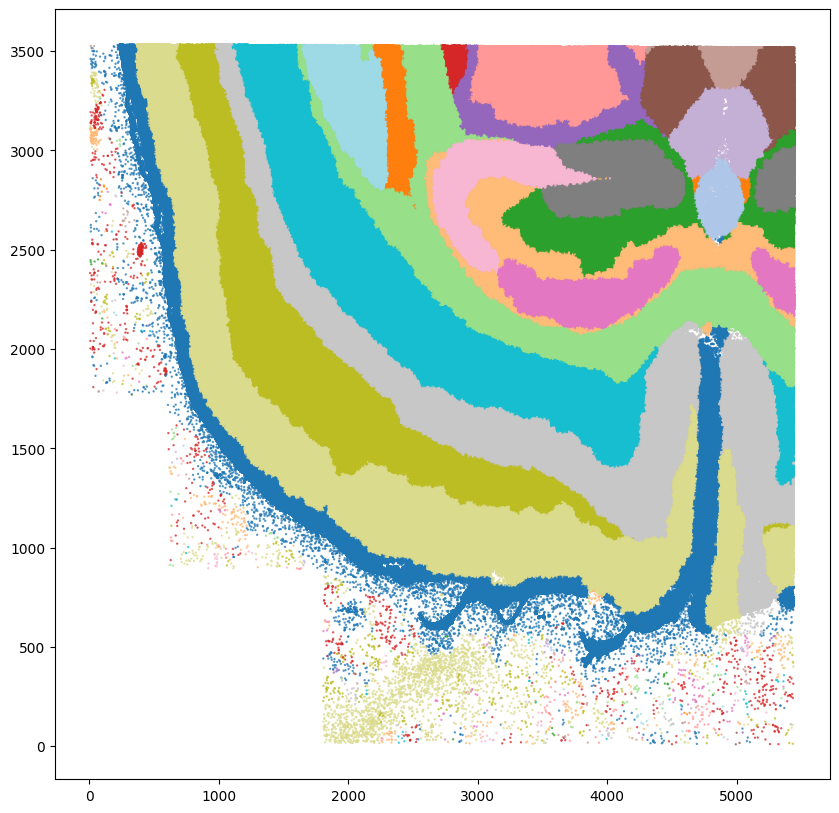

In [16]:
import matplotlib.pyplot as plt

# Plot the clusters
plt.figure(figsize=(10, 10))
data_by_cluster = data.query('Clusters != -1')

plt.scatter(
    data_by_cluster['x_location'], 
    data_by_cluster['y_location'], 
    c=data_by_cluster['Clusters'], 
    alpha=0.7, 
    s=0.5, 
    cmap='tab20'
)
plt.show()